In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [3]:
data = pd.read_csv("Cardiovascular_Disease_Dataset/Cardiovascular_Disease_Dataset.csv")
data.head()

,patientid,age,gender,chestpain,restingBP,serumcholestrol,fastingbloodsugar,restingrelectro,maxheartrate,exerciseangia,oldpeak,slope,noofmajorvessels,target
0,103368,53,1,2,171,0,0,1,147,0,5.3,3,3,1
1,119250,40,1,0,94,229,0,1,115,0,3.7,1,1,0
2,119372,49,1,2,133,142,0,0,202,1,5.0,1,0,0
3,132514,43,1,0,138,295,1,1,153,0,3.2,2,2,1
4,146211,31,1,1,199,0,0,2,136,0,5.3,3,2,1


In [4]:
del data['patientid']

In [5]:
data = data.dropna()

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                1000 non-null   int64  
 1   gender             1000 non-null   int64  
 2   chestpain          1000 non-null   int64  
 3   restingBP          1000 non-null   int64  
 4   serumcholestrol    1000 non-null   int64  
 5   fastingbloodsugar  1000 non-null   int64  
 6   restingrelectro    1000 non-null   int64  
 7   maxheartrate       1000 non-null   int64  
 8   exerciseangia      1000 non-null   int64  
 9   oldpeak            1000 non-null   float64
 10  slope              1000 non-null   int64  
 11  noofmajorvessels   1000 non-null   int64  
 12  target             1000 non-null   int64  
dtypes: float64(1), int64(12)
memory usage: 109.4 KB


In [7]:
data['target'].value_counts()#.plot(kind='bar');

1    580
0    420
Name: target, dtype: int64

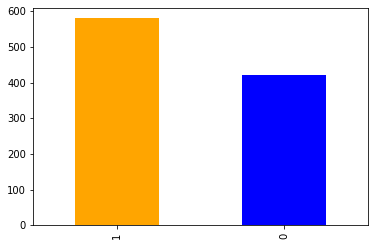

In [8]:
data['target'].value_counts().plot(kind='bar',color=['orange','blue']);

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                1000 non-null   int64  
 1   gender             1000 non-null   int64  
 2   chestpain          1000 non-null   int64  
 3   restingBP          1000 non-null   int64  
 4   serumcholestrol    1000 non-null   int64  
 5   fastingbloodsugar  1000 non-null   int64  
 6   restingrelectro    1000 non-null   int64  
 7   maxheartrate       1000 non-null   int64  
 8   exerciseangia      1000 non-null   int64  
 9   oldpeak            1000 non-null   float64
 10  slope              1000 non-null   int64  
 11  noofmajorvessels   1000 non-null   int64  
 12  target             1000 non-null   int64  
dtypes: float64(1), int64(12)
memory usage: 109.4 KB


In [10]:
from sklearn.metrics import accuracy_score, classification_report

In [11]:
X = data.drop(["target"],axis =1)
y = data["target"]

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((800, 12), (800,), (200, 12), (200,))

# XGBoost

In [13]:
from xgboost import XGBClassifier

# instantiate the model 
clf = XGBClassifier()

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

val1 = accuracy_score(y_pred, y_test)
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96        83
           1       0.97      0.97      0.97       117

    accuracy                           0.97       200
   macro avg       0.97      0.97      0.97       200
weighted avg       0.97      0.97      0.97       200



# Random Forest

In [14]:
from sklearn.ensemble import RandomForestClassifier

# instantiate the model 
clf = RandomForestClassifier()

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

val2 = accuracy_score(y_pred, y_test)
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        83
           1       0.98      0.98      0.98       117

    accuracy                           0.98       200
   macro avg       0.98      0.98      0.98       200
weighted avg       0.98      0.98      0.98       200



# Decision Tree

In [15]:
from sklearn.tree import DecisionTreeClassifier

# instantiate the model 
clf = DecisionTreeClassifier()

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

val3 = accuracy_score(y_pred, y_test)
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.94      0.96      0.95        81
           1       0.97      0.96      0.97       119

    accuracy                           0.96       200
   macro avg       0.96      0.96      0.96       200
weighted avg       0.96      0.96      0.96       200



# Logistic Regression

In [16]:
from sklearn.linear_model import LogisticRegression

# instantiate the model 
clf = LogisticRegression()

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

val4 = accuracy_score(y_pred, y_test)
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.90      0.96      0.93        78
           1       0.97      0.93      0.95       122

    accuracy                           0.94       200
   macro avg       0.94      0.95      0.94       200
weighted avg       0.95      0.94      0.95       200



# SVM

In [17]:
from sklearn.svm import SVC

# instantiate the model 
clf = SVC(probability=True)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

val5 = accuracy_score(y_pred, y_test)
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.84      0.80      0.82        87
           1       0.85      0.88      0.87       113

    accuracy                           0.85       200
   macro avg       0.85      0.84      0.85       200
weighted avg       0.85      0.85      0.85       200



# RS-CV  

# XGBoost

In [19]:
from sklearn.model_selection import RandomizedSearchCV
import xgboost
classifier = xgboost.XGBClassifier()

parameters = {"learning_rate": [0.1, 0.01, 0.001],
               "gamma" : [0.01, 0.1, 0.3, 0.5, 1, 1.5, 2],
               "max_depth": [2, 4, 7, 10],
               "colsample_bytree": [0.3, 0.6, 0.8, 1.0],
               "subsample": [0.2, 0.4, 0.5, 0.6, 0.7],
               "reg_alpha": [0, 0.5, 1],
               "reg_lambda": [1, 1.5, 2, 3, 4.5],
               "min_child_weight": [1, 3, 5, 7],
               "n_estimators": [10, 25, 50, 100]}

xgb_rscv = RandomizedSearchCV(classifier, param_distributions = parameters, scoring = "accuracy",
                             cv = 7, verbose = 3, random_state = 40)

xgb_rscv.fit(X_train, y_train)

# Print the best set of hyperparameters and the corresponding score
print("Best set of hyperparameters: ", xgb_rscv.best_params_)
print("Best score: ", xgb_rscv.best_score_)

Fitting 7 folds for each of 10 candidates, totalling 70 fits
[CV 1/7] END colsample_bytree=1.0, gamma=1.5, learning_rate=0.1, max_depth=2, min_child_weight=5, n_estimators=10, reg_alpha=0, reg_lambda=1, subsample=0.6;, score=0.948 total time=   0.0s
[CV 2/7] END colsample_bytree=1.0, gamma=1.5, learning_rate=0.1, max_depth=2, min_child_weight=5, n_estimators=10, reg_alpha=0, reg_lambda=1, subsample=0.6;, score=0.957 total time=   0.0s
[CV 3/7] END colsample_bytree=1.0, gamma=1.5, learning_rate=0.1, max_depth=2, min_child_weight=5, n_estimators=10, reg_alpha=0, reg_lambda=1, subsample=0.6;, score=0.886 total time=   0.0s
[CV 4/7] END colsample_bytree=1.0, gamma=1.5, learning_rate=0.1, max_depth=2, min_child_weight=5, n_estimators=10, reg_alpha=0, reg_lambda=1, subsample=0.6;, score=0.851 total time=   0.0s
[CV 5/7] END colsample_bytree=1.0, gamma=1.5, learning_rate=0.1, max_depth=2, min_child_weight=5, n_estimators=10, reg_alpha=0, reg_lambda=1, subsample=0.6;, score=0.947 total time=  

[CV 2/7] END colsample_bytree=0.6, gamma=0.3, learning_rate=0.001, max_depth=7, min_child_weight=7, n_estimators=25, reg_alpha=0.5, reg_lambda=1, subsample=0.7;, score=0.939 total time=   0.0s
[CV 3/7] END colsample_bytree=0.6, gamma=0.3, learning_rate=0.001, max_depth=7, min_child_weight=7, n_estimators=25, reg_alpha=0.5, reg_lambda=1, subsample=0.7;, score=0.921 total time=   0.0s
[CV 4/7] END colsample_bytree=0.6, gamma=0.3, learning_rate=0.001, max_depth=7, min_child_weight=7, n_estimators=25, reg_alpha=0.5, reg_lambda=1, subsample=0.7;, score=0.868 total time=   0.0s
[CV 5/7] END colsample_bytree=0.6, gamma=0.3, learning_rate=0.001, max_depth=7, min_child_weight=7, n_estimators=25, reg_alpha=0.5, reg_lambda=1, subsample=0.7;, score=0.974 total time=   0.0s
[CV 6/7] END colsample_bytree=0.6, gamma=0.3, learning_rate=0.001, max_depth=7, min_child_weight=7, n_estimators=25, reg_alpha=0.5, reg_lambda=1, subsample=0.7;, score=0.947 total time=   0.0s
[CV 7/7] END colsample_bytree=0.6, 

In [20]:
best_params = xgb_rscv.best_params_
clf = xgboost.XGBClassifier(**best_params)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

val6 = accuracy_score(y_pred, y_test)
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.89      0.93      0.91        80
           1       0.95      0.93      0.94       120

    accuracy                           0.93       200
   macro avg       0.92      0.93      0.92       200
weighted avg       0.93      0.93      0.93       200



# Random Forest

In [21]:
rfc_search_space = {
    'n_estimators': range(10, 101),
    'criterion': ['gini', 'entropy'],
    'max_depth': range(2, 51),
    'min_samples_split': range(2, 11),
    'min_samples_leaf': range(1, 11),
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}

random_search = RandomizedSearchCV(estimator=RandomForestClassifier(), param_distributions=rfc_search_space, n_iter=100, cv=5)
random_search.fit(X_train, y_train)

# Print the best set of hyperparameters and the corresponding score
print("Best set of hyperparameters: ", random_search.best_params_)
print("Best score: ", random_search.best_score_)

Best set of hyperparameters:  {'n_estimators': 52, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 24, 'criterion': 'entropy', 'bootstrap': False}
Best score:  0.97625


In [22]:
best_params = random_search.best_params_
clf = RandomForestClassifier(**best_params)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

val7 = accuracy_score(y_pred, y_test)
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98        82
           1       0.99      0.98      0.99       118

    accuracy                           0.98       200
   macro avg       0.98      0.99      0.98       200
weighted avg       0.99      0.98      0.99       200



# Decision Tree

In [23]:
# Import necessary modules
from scipy.stats import randint

param_dist = {"max_depth": [3, None],
              "max_features": randint(1, 9),
              "min_samples_leaf": randint(1, 9),
              "criterion": ["gini", "entropy"]}

# Instantiate a Decision Tree classifier: tree
tree = DecisionTreeClassifier()

# Instantiate the RandomizedSearchCV object: tree_cv
tree_cv = RandomizedSearchCV(tree, param_dist, cv=5)

# Fit it to the data
tree_cv.fit(X_train,y_train)

# Print the tuned parameters and score
print("Tuned Decision Tree Parameters: {}".format(tree_cv.best_params_))
print("Best score is {}".format(tree_cv.best_score_))

Tuned Decision Tree Parameters: {'criterion': 'gini', 'max_depth': None, 'max_features': 7, 'min_samples_leaf': 4}
Best score is 0.9525


In [24]:
best_params = tree_cv.best_params_
clf = DecisionTreeClassifier(**best_params)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

val8 = accuracy_score(y_pred, y_test)
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.94      0.94      0.94        83
           1       0.96      0.96      0.96       117

    accuracy                           0.95       200
   macro avg       0.95      0.95      0.95       200
weighted avg       0.95      0.95      0.95       200



# Logistic Regression

In [25]:
C = np.logspace(0, 4, num=10)
penalty = ['l1', 'l2']
solver = ['liblinear', 'saga']

hyperparameters = dict(C=C, penalty=penalty, solver=solver)

logistic = LogisticRegression()
gridsearch = RandomizedSearchCV(logistic, hyperparameters)
best_model = gridsearch.fit(X_train, y_train)
print(best_model.best_estimator_)

LogisticRegression(C=7.742636826811269, penalty='l1', solver='liblinear')


In [26]:
best_params = best_model.best_params_
clf = LogisticRegression(**best_params)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

val9 = accuracy_score(y_pred, y_test)
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.94      0.96      0.95        81
           1       0.97      0.96      0.97       119

    accuracy                           0.96       200
   macro avg       0.96      0.96      0.96       200
weighted avg       0.96      0.96      0.96       200



# SVM

In [27]:
param_dist = {
    'C' : [0.1,1,10,100],
    'gamma' : [1,0.1,0.01,0.001],
    'kernel' : ['rbf', 'linear']
}

gridsearch = RandomizedSearchCV(SVC(), param_dist, n_iter=1)
best_model = gridsearch.fit(X_train, y_train)
print(best_model.best_estimator_)

SVC(C=0.1, gamma=0.1, kernel='linear')


In [28]:
best_params = best_model.best_params_
clf = SVC(**best_params)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

val10 = accuracy_score(y_pred, y_test)
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.98      0.96      0.97        84
           1       0.97      0.98      0.98       116

    accuracy                           0.97       200
   macro avg       0.98      0.97      0.97       200
weighted avg       0.98      0.97      0.97       200



# GS-CV

# XGBoost

In [61]:
from sklearn.model_selection import GridSearchCV

# Define the hyperparameter grid
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.1, 0.01, 0.001],
    'subsample': [0.5, 0.7, 1]
}

# Create the XGBoost model object
xgb_model = XGBClassifier()

# Create the GridSearchCV object
grid_search = GridSearchCV(xgb_model, param_grid, cv=5, scoring='accuracy')

grid_search.fit(X_train, y_train)

# Print the best set of hyperparameters and the corresponding score
print("Best set of hyperparameters: ", grid_search.best_params_)
print("Best score: ", grid_search.best_score_)

Best set of hyperparameters:  {'learning_rate': 0.1, 'max_depth': 5, 'subsample': 1}
Best score:  0.898109672085974


In [29]:
clf = XGBClassifier(learning_rate='0.1',subsample=1,max_depth=5,n_estimators=180)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

val11 = accuracy_score(y_pred, y_test)
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.95      0.98      0.96        81
           1       0.98      0.97      0.97       119

    accuracy                           0.97       200
   macro avg       0.97      0.97      0.97       200
weighted avg       0.97      0.97      0.97       200



# Random Forest

In [63]:
grid_space={'max_depth':[3,5,10,None],
              'n_estimators':[10,100,200],
              'max_features':[1,3,5,7],
              'min_samples_leaf':[1,2,3],
              'min_samples_split':[1,2,3]
           }

grid = GridSearchCV(RandomForestClassifier(),param_grid=grid_space,cv=3,scoring='accuracy')
grid.fit(X_train,y_train)

print("Best set of hyperparameters: ", grid.best_params_)
print("Best score: ", grid.best_score_)

Best set of hyperparameters:  {'max_depth': None, 'max_features': 1, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best score:  0.9106898398904827


In [30]:
clf = RandomForestClassifier(criterion='entropy',max_depth=None,n_estimators=200,min_samples_leaf=1,min_samples_split=2)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

val12 = accuracy_score(y_pred, y_test)
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.99      0.98      0.98        84
           1       0.98      0.99      0.99       116

    accuracy                           0.98       200
   macro avg       0.99      0.98      0.98       200
weighted avg       0.99      0.98      0.98       200



# DecisionTree

In [65]:
param_grid = {'max_features': ['auto', 'sqrt', 'log2'],
              'ccp_alpha': [0.1, .01, .001],
              'max_depth' : [5, 6, 7, 8, 9],
              'criterion' :['gini', 'entropy']
             }

grid_search = GridSearchCV(estimator=DecisionTreeClassifier(), param_grid=param_grid, cv=5, verbose=True)
grid_search.fit(X_train, y_train)

# Print the best set of hyperparameters and the corresponding score
print("Best set of hyperparameters: ", grid_search.best_params_)
print("Best score: ", grid_search.best_score_)

Fitting 5 folds for each of 90 candidates, totalling 450 fits
Best set of hyperparameters:  {'ccp_alpha': 0.001, 'criterion': 'entropy', 'max_depth': 8, 'max_features': 'auto'}
Best score:  0.8413392119041058


In [31]:
clf = DecisionTreeClassifier(criterion='gini',max_features='auto',max_depth=8,ccp_alpha=0.001,min_samples_split=2,splitter='best')

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

val13 = accuracy_score(y_pred, y_test)
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.95      0.94      0.95        84
           1       0.96      0.97      0.96       116

    accuracy                           0.95       200
   macro avg       0.95      0.95      0.95       200
weighted avg       0.95      0.95      0.95       200



# LogisticRegression

In [67]:
grid={"C":np.logspace(-3,3,7), "penalty":["l1","l2"]}# l1 lasso l2 ridge
logreg=LogisticRegression()
logreg_cv=GridSearchCV(logreg,grid,cv=10)
logreg_cv.fit(X_train,y_train)

print("tuned hpyerparameters :(best parameters) ",logreg_cv.best_params_)
print("accuracy :",logreg_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'C': 1000.0, 'penalty': 'l2'}
accuracy : 0.8160855263157896


In [32]:
clf = LogisticRegression(C=1000.0,max_iter=100,multi_class='auto',intercept_scaling=1,penalty='l2',tol=0.0001,solver='lbfgs')

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

val14 = accuracy_score(y_pred, y_test)
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.92      0.96      0.94        79
           1       0.97      0.94      0.96       121

    accuracy                           0.95       200
   macro avg       0.95      0.95      0.95       200
weighted avg       0.95      0.95      0.95       200



# SVM

In [68]:
param_grid = {'C': [0.1, 1, 10, 100, 1000],  
              'gamma': [1, 0.1, 0.01, 0.001, 0.0001], 
              'kernel': ['rbf']}  
  
grid = GridSearchCV(SVC(), param_grid, refit = True, verbose = 3) 
  
# fitting the model for grid search 
grid.fit(X_train, y_train) 

print("Best set of hyperparameters: ", grid.best_params_)
print("Best score: ", grid.best_score_)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.524 total time=   0.0s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.524 total time=   0.0s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.526 total time=   0.0s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.521 total time=   0.0s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.521 total time=   0.0s
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.524 total time=   0.0s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.524 total time=   0.0s
[CV 3/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.526 total time=   0.0s
[CV 4/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.521 total time=   0.0s
[CV 5/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.521 total time=   0.0s
[CV 1/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.524 total time=   0.0s
[CV 2/5] END .....C=0.1, gamma=0.01, kernel=rbf

[CV 3/5] END .......C=1000, gamma=1, kernel=rbf;, score=0.674 total time=   0.0s
[CV 4/5] END .......C=1000, gamma=1, kernel=rbf;, score=0.700 total time=   0.0s
[CV 5/5] END .......C=1000, gamma=1, kernel=rbf;, score=0.705 total time=   0.0s
[CV 1/5] END .....C=1000, gamma=0.1, kernel=rbf;, score=0.696 total time=   0.0s
[CV 2/5] END .....C=1000, gamma=0.1, kernel=rbf;, score=0.681 total time=   0.0s
[CV 3/5] END .....C=1000, gamma=0.1, kernel=rbf;, score=0.684 total time=   0.0s
[CV 4/5] END .....C=1000, gamma=0.1, kernel=rbf;, score=0.726 total time=   0.0s
[CV 5/5] END .....C=1000, gamma=0.1, kernel=rbf;, score=0.711 total time=   0.0s
[CV 1/5] END ....C=1000, gamma=0.01, kernel=rbf;, score=0.812 total time=   0.0s
[CV 2/5] END ....C=1000, gamma=0.01, kernel=rbf;, score=0.770 total time=   0.0s
[CV 3/5] END ....C=1000, gamma=0.01, kernel=rbf;, score=0.758 total time=   0.0s
[CV 4/5] END ....C=1000, gamma=0.01, kernel=rbf;, score=0.779 total time=   0.0s
[CV 5/5] END ....C=1000, gam

In [33]:
clf = SVC(probability=True,C=1000,cache_size=200,decision_function_shape='ovr',tol=0.0001,degree=3,kernel='rbf',gamma=0.0001,max_iter=-1)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

val15 = accuracy_score(y_pred, y_test)
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95        83
           1       0.97      0.97      0.97       117

    accuracy                           0.96       200
   macro avg       0.96      0.96      0.96       200
weighted avg       0.96      0.96      0.96       200



# DT + RF Tuned XGB

In [34]:
from sklearn.ensemble import StackingClassifier

clf1 = RandomForestClassifier(criterion='entropy',max_depth=None,n_estimators=200,min_samples_leaf=1,min_samples_split=2)
clf2 = DecisionTreeClassifier(criterion='gini',max_features='auto',max_depth=8,ccp_alpha=0.001,min_samples_split=2,splitter='best')

estimators = [('rf', clf1),('dt', clf2)]

clf3 = XGBClassifier(learning_rate='0.1',subsample=1,max_depth=5,n_estimators=180)

clf = StackingClassifier(estimators=estimators, final_estimator=clf3)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

val16 = accuracy_score(y_pred, y_test)
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.95      0.98      0.96        81
           1       0.98      0.97      0.97       119

    accuracy                           0.97       200
   macro avg       0.97      0.97      0.97       200
weighted avg       0.97      0.97      0.97       200



# Extension

In [35]:
from sklearn.ensemble import VotingClassifier, BaggingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

bdt = AdaBoostClassifier(
    DecisionTreeClassifier(max_depth=1), algorithm="SAMME", n_estimators=200
)

model = VotingClassifier(estimators= [('BoostDT', bdt),('RF', rf)], voting='soft')

model.fit(X_train, y_train)
predictions = model.predict(X_test)
val17 = accuracy_score(y_test, predictions)

In [36]:
print(classification_report(predictions, y_test))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99        83
           1       0.99      0.99      0.99       117

    accuracy                           0.99       200
   macro avg       0.99      0.99      0.99       200
weighted avg       0.99      0.99      0.99       200



# Comparison

In [37]:
results=pd.DataFrame({'Model':['XGB','RF','DT','LR','SVM','RS-XGB','RS-RF','RS-DT','RS-LR','RS-SVM','GS-XGB','GS-RF','GS-DT','GS-LR','GS-SVM','Tuned RF-DT-Meta XGB','Extension'],
                    'Accuracy Score':[val1,val2,val3,val4,val5,val6,val7,val8,val9,val10,val11,val12,val13,val14,val15,val16,val17]})
result_df=results.sort_values(by='Accuracy Score', ascending=False)
result_df=result_df.set_index('Model')
result_df

,Accuracy Score
Model,
Extension,0.990
GS-RF,0.985
RS-RF,0.985
RF,0.980
RS-SVM,0.975
Tuned RF-DT-Meta XGB,0.970
GS-XGB,0.970
XGB,0.970
GS-SVM,0.960


# Modelling

In [38]:
import joblib
#filename = 'model.sav'
joblib.dump(model, 'model2.sav')

['model2.sav']

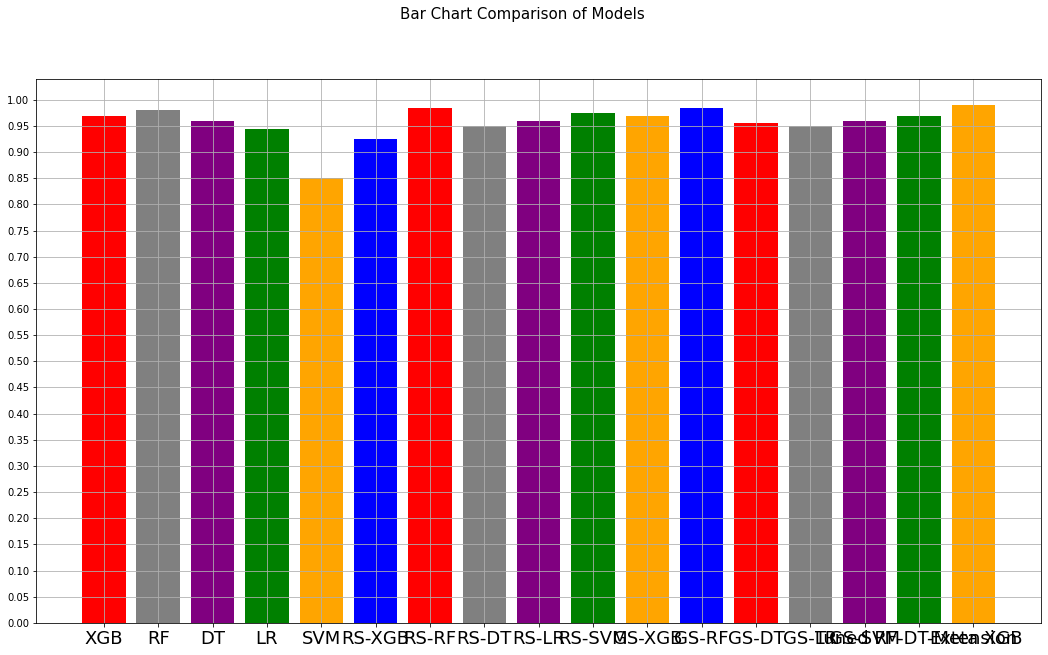

In [39]:
algorithms=('XGB','RF','DT','LR','SVM','RS-XGB','RS-RF','RS-DT','RS-LR','RS-SVM','GS-XGB','GS-RF','GS-DT','GS-LR','GS-SVM','Tuned RF-DT-Meta XGB','Extension')
scores = (val1,val2,val3,val4,val5,val6,val7,val8,val9,val10,val11,val12,val13,val14,val15,val16,val17)
y_pos = np.arange(1,18)
colors = ("red","gray","purple","green","orange","blue")
plt.figure(figsize=(18,10))
plt.bar(y_pos,scores,color=colors)
plt.xticks(y_pos,algorithms,fontsize=18)
plt.yticks(np.arange(0.00, 1.01, step=0.05))
plt.grid()
plt.suptitle("Bar Chart Comparison of Models",fontsize=15)
plt.show()